Extracting the learning set and test set from the .txt file that generated during eucildean distance

In [1]:
seed_value = 10
h_neurons = 16
l_rate = 0.00183

In [2]:

def extract_L_set(filepath):
    l_set = []
    capture = False
    with open(filepath, 'r') as file:
        for line in file:
            line = line.strip()
        
            # Start capturing when we see the header
            if line.startswith("L set:"):
                capture = True
                continue
        
            # Stop capturing when we reach the B vector
            if line.startswith("B vector:"):
                capture = False
                break
            
            # If we are in the capture zone and the line looks like a list
            if capture and line.startswith("["):
                # ast.literal_eval safely converts the string "[1, 2...]" into a Python list
                row = ast.literal_eval(line)
                l_set.append(row)
    return l_set

Remember not to change the seed value, it is really important to get the exact result everytime, without changing the model's parameters. Without seed, every run gives different result thought the parameters are same. 

In [3]:
import numpy as np
import ast #abstract syntax tree module for safe evaluation of string.
import random
loaded_train_test_data = []
#first we loading the L set from 2003 to 2023
filePath = '../ED_Calculation/2003_2023/results/finalize_L_set_from_2003_to_2023.txt'
loaded_learning_data = np.array(extract_L_set(filePath))
random.seed(seed_value)
np.random.seed(seed_value)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#separate the training_validation for Feature and Target
X = loaded_learning_data[:, :5] #first five col of the row is feature
y = loaded_learning_data[:, 5] # 6th value is the target

#split for train and val
X_train = X[30:]
X_val = X[:30]
y_train = y[30:]
y_val = y[:30]

scaler =  StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print(f"Shape of X_train {X_train.shape}")
print(f"Shape of y_train{y_train.shape}")
print(f"Shape of X_val{X_val.shape}")
print(f"Shape of y_val{y_val.shape}")

Shape of X_train (115, 5)
Shape of y_train(115,)
Shape of X_val(30, 5)
Shape of y_val(30,)


It is time to define the test data from **2024 to 2025**.

In [5]:
loaded_test_data = []
test_filepath = "../ED_Calculation/2024_current/results/final_result_df_2024_2025.txt"
loaded_test_data = np.array(extract_L_set(test_filepath))
X_test = loaded_test_data[:, :5]
y_test = loaded_test_data[:, 5]

X_test = scaler.transform(X_test)


Now we are going to make a Feed Forward Neural Network, which has input layer with 5 feature, a hidden layer with initial neuron size 10 with signmoid function, and a signle neuron output layer with linear function.

In [6]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
tf.random.set_seed(seed_value)

# ffnn's parameters
epoch_size = 30
b_size = 8

#Create a model
ffnn = Sequential()
# Input layer (5 features)
ffnn.add(Input(shape=(X_train.shape[1],)))

ffnn.add(Dense(units=h_neurons, activation="sigmoid",))
ffnn.add(Dense(units=1, activation="linear"))
ffnn.summary()


I0000 00:00:1779283974.459783 1204815 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779283974.587250 1204815 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779283976.392492 1204815 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1779283977.291607 1204815 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113 (452.00 B)

 Trainable params: 113 (452.00 B)

 Non-trainable params: 0 (0.00 B)

Now compile and run the model

ModelCheckpoint is a callback function to help to save the model's configuration during every epoch.

In [7]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam

class PrintValAccuracyOnly(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        # Fetch the validation accuracy from the logs
        val_acc = logs.get('val_direction_accuracy')
        if val_acc is not None:
            print(f"Epoch {epoch + 1}: val_direction_accuracy: {val_acc:.4f}%")

def direction_accuracy(y_true, y_pred):
    true_sign = tf.sign(y_true)
    pred_sign = tf.sign(y_pred)
    matches = tf.equal(true_sign, pred_sign)
    return tf.reduce_mean(tf.cast(matches, tf.float32)) * 100
    


early_stopping = EarlyStopping(
    monitor='val_direction_accuracy', 
    mode='max',                       
    patience=5,                       
    restore_best_weights=True         
)


checkpoint = ModelCheckpoint(
    filepath=f'models/best_model.keras',
    monitor='val_direction_accuracy',
    save_weights_only= False,
    mode='max',
    save_best_only=True,              # Only save when the accuracy improves
    verbose=0
)


ffnn.compile(
    optimizer=Adam(learning_rate=l_rate), 
    loss='mse', 
    metrics=[direction_accuracy]      # Track this during training
)


print("Starting training... and evaluating validation")
ffnn_history = ffnn.fit(
    X_train, y_train, 
    validation_data=(X_val, y_val),   # Calculate validation metrics per epoch
    epochs=epoch_size, 
    batch_size=b_size,
    callbacks=[early_stopping, checkpoint, PrintValAccuracyOnly()],
    verbose=0
)

Starting training... and evaluating validation
Epoch 1: val_direction_accuracy: 54.1667%
Epoch 2: val_direction_accuracy: 53.0382%
Epoch 3: val_direction_accuracy: 53.5590%
Epoch 4: val_direction_accuracy: 49.6528%
Epoch 5: val_direction_accuracy: 44.1840%
Epoch 6: val_direction_accuracy: 44.6181%


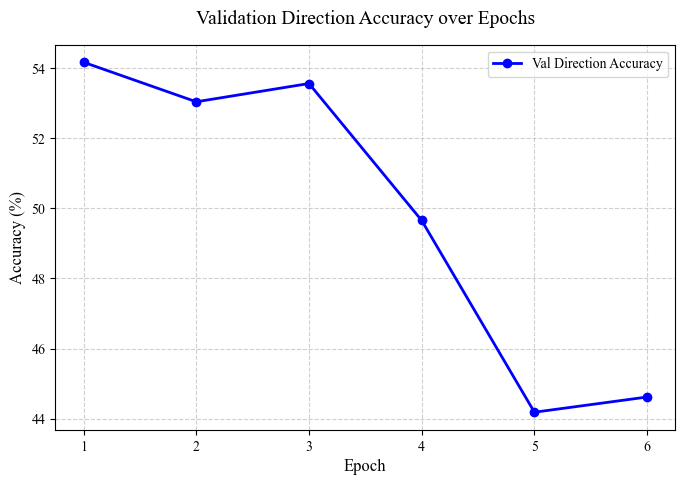

In [8]:
import matplotlib.pyplot as plt


epochs = [1, 2, 3, 4, 5, 6]
val_accuracy = [54.1667, 53.0382, 53.5590, 49.6528, 44.1840, 44.6181]
plt.rcParams['font.family'] = 'Times New Roman'

plt.figure(figsize=(8, 5))
plt.plot(epochs, val_accuracy, marker='o', linestyle='-', color='b', linewidth=2, label='Val Direction Accuracy')


plt.title('Validation Direction Accuracy over Epochs', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xticks(epochs)  # Ensures only integer epoch numbers show on the x-axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best')
plt.savefig("sigmoid_val_accuracy_over_epoch.png", dpi=300, bbox_inches="tight")
plt.show()

After trained the model, we are going to check and evaluate these 200 configs based on the validation set, using "correct directional percentage change". 
The best model configuratoion will be saved which gives biggest correct directional percentage change on the validation data set.

In here, we are going to select that best model, and evaluate the **prediction** against validation set.

In [9]:
import pandas as pd
import numpy as np
import tensorflow as tf

best_model_path = f'models/best_model.keras'

best_model = tf.keras.models.load_model(best_model_path, compile=False)


y_val_pred = best_model.predict(X_val)

y_val_actual = np.ravel(y_val)
y_val_pred_flat = np.ravel(y_val_pred)

val_direction_match = (np.sign(y_val_actual) == np.sign(y_val_pred_flat)).astype(int)

val_results_df = pd.DataFrame({
    'Actual': y_val_actual,
    'Predicted': y_val_pred_flat,
    'Direction': val_direction_match
})

val_neg_match = ((val_results_df['Actual'] < 0) & (val_results_df['Predicted'] < 0)).sum()

# Count where actual > 0 AND predicted > 0  (positive match)
val_pos_match = ((val_results_df['Actual'] > 0) & (val_results_df['Predicted'] > 0)).sum()

print(f"--- Predictions for Best Model (from {best_model_path}) ---")
print(val_results_df)

final_val_acc = val_results_df['Direction'].mean() * 100
print(f"\nValidation Prediction Accuracy: {final_val_acc:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
--- Predictions for Best Model (from models/best_model.keras) ---
      Actual  Predicted  Direction
0   0.449403  -0.172575          0
1  -1.033273  -0.411088          1
2  -1.028040  -0.918648          1
3  -1.118594  -0.431247          1
4   0.304173  -0.928288          0
5   0.237958  -0.195846          0
6  -0.179998  -0.397174          1
7  -1.305160  -0.536917          1
8   1.118788  -0.616671          0
9  -0.404159  -0.189256          1
10  0.274649  -0.511015          0
11  0.105960  -0.086920          0
12  0.726266  -0.178599          0
13 -0.662117  -0.294749          1
14 -0.114420  -0.483112          1
15 -0.238144  -0.446631          1
16 -0.521055  -0.278543          1
17  0.064410  -0.386205          0
18 -0.177229  -0.426025          1
19 -0.075720  -0.633251          1
20 -0.691956  -0.289631          1
21 -0.058821  -0.116665          1
22 -0.192841  -0.576347          1
23 -0.885929  -0.309908          1
24  0.297621  -0.7211

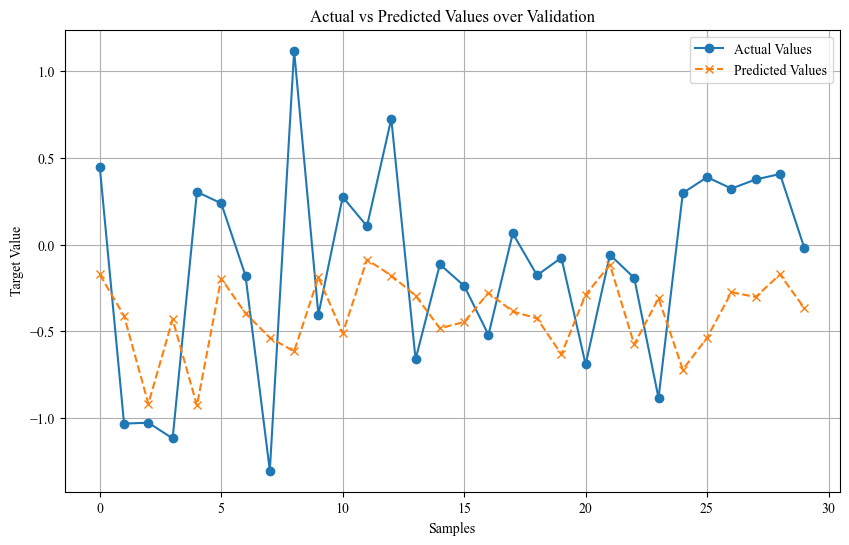

In [10]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_val_actual)), y_val_actual, label="Actual Values", marker="o")
plt.plot(range(len(y_val_pred_flat)), y_val_pred_flat, label="Predicted Values", marker="x", linestyle="--")
plt.title("Actual vs Predicted Values over Validation")
plt.xlabel("Samples")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.show()

Again, load that best model for final evaluation with the test set.

In [11]:
# Load the best model
final_model = tf.keras.models.load_model(
    best_model_path, 
    custom_objects={'direction_accuracy': direction_accuracy},
    compile=False
)
final_model.compile(
    optimizer='adam',
    loss='mse', 
    metrics=[direction_accuracy]
)


test_results = final_model.evaluate(X_test, y_test, verbose=1)

print("-" * 30)
print(f"FINAL TEST SET EVALUATED")
print("-" * 30)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - direction_accuracy: 45.4545 - loss: 0.1461
------------------------------
FINAL TEST SET EVALUATED
------------------------------


Get the prediction against test set.

In [12]:

y_pred = final_model.predict(X_test)


y_test_flat = np.ravel(y_test)
y_pred_flat = np.ravel(y_pred)


direction_match = (np.sign(y_test_flat) == np.sign(y_pred_flat)).astype(int)

import pandas as pd

results_df = pd.DataFrame({
    'Actual': y_test_flat,
    'Predicted': y_pred_flat,
    'Direction': direction_match
})
test_neg_match = ((results_df['Actual'] < 0) & (results_df['Predicted'] < 0)).sum()

# Count where actual > 0 AND predicted > 0  (positive match)
test_pos_match = ((results_df['Actual'] > 0) & (results_df['Predicted'] > 0)).sum()

print(results_df)
final_test_acc = results_df['Direction'].mean() * 100
print(f"\nTest Prediction Accuracy: {final_test_acc:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
      Actual  Predicted  Direction
0  -0.017473  -0.355520          1
1  -0.339443  -0.447229          1
2   0.031541  -0.175785          0
3  -0.215161  -0.220170          1
4  -0.087107  -0.225724          1
5   0.485383  -0.014811          0
6  -0.220254  -0.563440          1
7   0.307394  -0.135080          0
8   0.306878  -0.232723          0
9   0.113420  -0.279002          0
10  0.198257  -0.442303          0

Test Prediction Accuracy: 45.45%


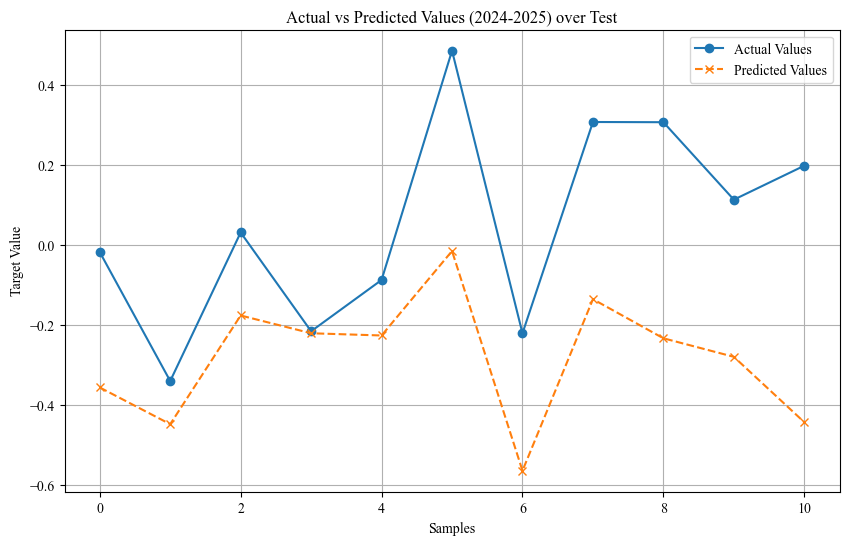

In [13]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test_flat)), y_test_flat, label="Actual Values", marker="o")
plt.plot(range(len(y_pred_flat)), y_pred_flat, label="Predicted Values", marker="x", linestyle="--")
plt.title("Actual vs Predicted Values (2024-2025) over Test")
plt.xlabel("Samples")
plt.ylabel("Target Value")
plt.legend()
plt.grid(True)
plt.show()

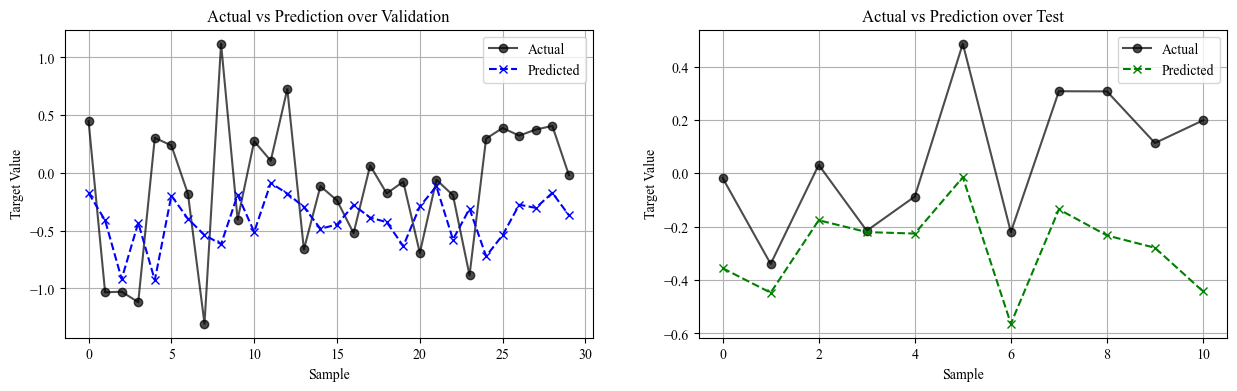

In [14]:
import matplotlib.pyplot as plt

# actual and predicted arrays
actual = y_test_flat
val = y_val
ffnn = y_pred_flat        # make sure it's 1D
ffnn_val = y_val_pred_flat

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# ----- Plot 1: FFNN actual vs val -----
axes[0].plot(range(len(y_val)), y_val, label="Actual", marker="o", color='black', alpha=0.7)
axes[0].plot(range(len(ffnn_val)),ffnn_val, label="Predicted", marker="x", linestyle="--", color='blue')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Target Value')
axes[0].set_title('Actual vs Prediction over Validation')
axes[0].legend()
axes[0].grid(True)

# ----- Plot 2: FFNN actual vs test-----
axes[1].plot(range(len(actual)), actual, label="Actual", marker="o", color='black', alpha=0.7)
axes[1].plot(range(len(ffnn)), ffnn, label="Predicted", marker="x", linestyle="--", color='green')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Target Value')
axes[1].set_title('Actual vs Prediction over Test')
axes[1].legend()
axes[1].grid(True)

plt.savefig("sigmoid_val_test.png", dpi=300, bbox_inches="tight")
